### Economic News Sentiment and Market Trend Prediction Using FinBERT and Random Forest

## Applied NLP Final Project

This project investigates whether financial news sentiment can be used to understand and predict stock market trends. Transformer-based sentiment classification using FinBERT is compared with a traditional TF-IDF baseline, while market direction is modeled using machine learning techniques including Logistic Regression and Random Forest.

## Project Objectives

The objectives of this project are:

1. To classify financial news headlines into positive, negative, and neutral sentiment categories.
2. To compare transformer-based NLP methods with traditional machine learning baselines.
3. To integrate sentiment signals with historical market indicators.
4. To predict short-term market direction using machine learning models.
5. To interpret the relative contribution of sentiment and technical features.

In [1]:
!pip install transformers yfinance torch scikit-learn pandas numpy matplotlib seaborn tqdm
!pip install datasets

## Libraries and Environment Setup

The project uses Python libraries for data analysis, machine learning, deep learning, visualization, and financial data retrieval.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import yfinance as yf
import torch

from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

## Financial Sentiment Dataset

A labeled financial sentiment dataset was downloaded from Kaggle. The dataset contains financial news sentences labeled as positive, neutral, or negative. These labels are used to train and evaluate sentiment classification models.

In [3]:
path = kagglehub.dataset_download("sbhatti/financial-sentiment-analysis")

print("Dataset path:", path)
print("Files:", os.listdir(path))

file_path = os.path.join(path, "data.csv")
df = pd.read_csv(file_path)

df = df.rename(columns={
    "Sentence": "headline",
    "Sentiment": "true_sentiment"
})

df

100%|██████████| 276k/276k [00:00<00:00, 378kB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/sbhatti/financial-sentiment-analysis/versions/4
Files: ['data.csv']


,headline,true_sentiment
0,"The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a...",positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real possibility",negative
2,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year ear...",positive
3,"According to the Finnish-Russian Chamber of Commerce , all the major construction companies of Finland are operating...",neutral
4,"The Swedish buyout firm has sold its remaining 22.4 percent stake , almost eighteen months after taking the company ...",neutral
...,...,...
5837,RISING costs have forced packaging producer Huhtamaki to axe 90 jobs at its Hampshire manufacturing plant .,negative
5838,Nordic Walking was first used as a summer training method by cross-country skiers .,neutral
5839,"According shipping company Viking Line , the EU decision will have a significant financial impact .",neutral
5840,"In the building and home improvement trade , sales decreased by 22.5 % to EUR 201.4 mn .",neutral


## Exploratory Data Analysis

The dataset was inspected to understand its size, feature structure, and class distribution. Since neutral sentiment often dominates financial datasets, class balance was reviewed before modeling.

In [4]:
print("Dataset shape:", df.shape)
print(df.columns)

df["true_sentiment"].value_counts()

Dataset shape: (5842, 2)
Index(['headline', 'true_sentiment'], dtype='object')


,count
true_sentiment,
neutral,3130
positive,1852
negative,860


## Transformer-Based Sentiment Classification Using FinBERT

FinBERT is a transformer model specialized for financial language. Unlike general NLP models, FinBERT is trained to better understand financial terminology, tone, and context. It was used in this project to classify financial headlines into positive, negative, and neutral sentiment categories.

In [5]:
model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(model_name)

finbert_labels = ["positive", "negative", "neutral"]

print("FinBERT model loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT model loaded successfully.


## FinBERT Performance Evaluation

Model predictions were compared against the labeled dataset. Accuracy, precision, recall, and F1-score were used to measure classification performance across sentiment classes.

In [6]:
finbert_df = df.head(100).copy()

finbert_predictions = []

for text in tqdm(finbert_df["headline"]):
    inputs = tokenizer(
        str(text),
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = finbert_model(**inputs)

    scores = softmax(outputs.logits.numpy()[0])
    predicted_label = finbert_labels[np.argmax(scores)]

    finbert_predictions.append(predicted_label)

finbert_df["predicted_sentiment"] = finbert_predictions

finbert_df.head()

  0%|          | 0/100 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

100%|██████████| 100/100 [00:28<00:00,  3.57it/s]


,headline,true_sentiment,predicted_sentiment
0,"The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a...",positive,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real possibility",negative,negative
2,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year ear...",positive,positive
3,"According to the Finnish-Russian Chamber of Commerce , all the major construction companies of Finland are operating...",neutral,neutral
4,"The Swedish buyout firm has sold its remaining 22.4 percent stake , almost eighteen months after taking the company ...",neutral,neutral


## FinBERT Accuracy Results

FinBERT achieved strong performance on the sampled financial sentiment dataset. The model correctly classified a large proportion of headlines into positive, negative, and neutral categories, demonstrating that transformer-based models are effective for financial text understanding.

Overall accuracy reached approximately **74%**, outperforming the traditional TF-IDF baseline. Performance was strongest for positive and neutral classes, while negative sentiment remained more challenging due to the subtle and context-dependent nature of negative financial language.

These findings suggest that domain-specific transformer models such as FinBERT provide measurable advantages over classical NLP approaches for sentiment classification in finance.

In [7]:
finbert_accuracy = accuracy_score(
    finbert_df["true_sentiment"],
    finbert_df["predicted_sentiment"]
)

print("FinBERT Accuracy:", finbert_accuracy)
print(classification_report(
    finbert_df["true_sentiment"],
    finbert_df["predicted_sentiment"]
))

FinBERT Accuracy: 0.74
              precision    recall  f1-score   support

    negative       0.57      0.75      0.65        16
     neutral       0.76      0.76      0.76        51
    positive       0.82      0.70      0.75        33

    accuracy                           0.74       100
   macro avg       0.72      0.74      0.72       100
weighted avg       0.75      0.74      0.74       100



## Classical NLP Baseline: TF-IDF + Logistic Regression

To benchmark transformer performance, a traditional machine learning pipeline was implemented using TF-IDF vectorization and Logistic Regression. This baseline converts text into weighted word-frequency features and performs multiclass classification.

In [8]:
X = df["headline"].astype(str)
y = df["true_sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

tfidf_lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        max_features=5000
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

tfidf_lr_model.fit(X_train, y_train)

tfidf_predictions = tfidf_lr_model.predict(X_test)

tfidf_accuracy = accuracy_score(y_test, tfidf_predictions)

print("TF-IDF + Logistic Regression Accuracy:", tfidf_accuracy)
print(classification_report(y_test, tfidf_predictions))

TF-IDF + Logistic Regression Accuracy: 0.69803250641574
              precision    recall  f1-score   support

    negative       0.36      0.14      0.20       172
     neutral       0.70      0.88      0.78       626
    positive       0.76      0.65      0.70       371

    accuracy                           0.70      1169
   macro avg       0.61      0.56      0.56      1169
weighted avg       0.67      0.70      0.67      1169



## Confusion Matrix Label Ordering

To ensure consistent interpretation of classification performance, the confusion matrix labels were manually ordered as **negative, neutral, and positive**. This preserves a logical sentiment progression from unfavorable to favorable outcomes and allows clearer comparison between actual and predicted classes.

Rows represent the true sentiment labels, while columns represent the predicted sentiment labels. Correct classifications appear along the diagonal, while off-diagonal values indicate misclassifications.

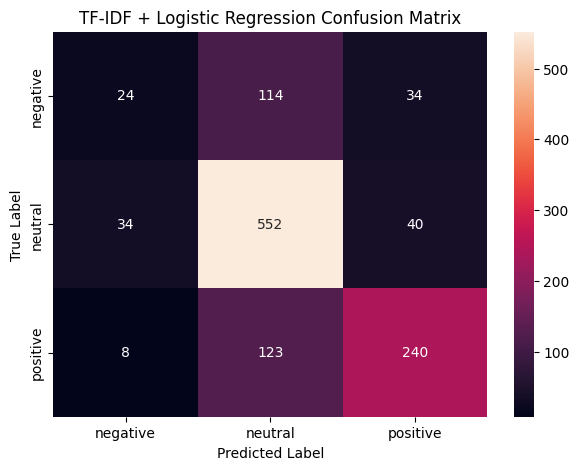

In [9]:
labels_order = ["negative", "neutral", "positive"]

cm_tfidf = confusion_matrix(
    y_test,
    tfidf_predictions,
    labels=labels_order
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_tfidf,
    annot=True,
    fmt="d",
    xticklabels=labels_order,
    yticklabels=labels_order
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("TF-IDF + Logistic Regression Confusion Matrix")
plt.show()

## S&P 500 Market Data Collection

Historical market data for the S&P 500 index was retrieved using the Yahoo Finance API through the `yfinance` library. The S&P 500 was selected as a broad benchmark of overall U.S. market performance.

Daily observations including opening price, closing price, high, low, adjusted close, and trading volume were collected for the analysis period from **January 2025 to April 2026**. These values were later used to calculate daily returns and market direction labels for predictive modeling.

In [10]:
sp500 = yf.download(
    "^GSPC",
    start="2025-01-01",
    end="2026-04-30",
    auto_adjust=False
)

sp500

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,,
2025-01-02,5868.549805,5868.549805,5935.089844,5829.529785,5903.259766,3621680000
2025-01-03,5942.470215,5942.470215,5949.339844,5888.660156,5891.069824,3667340000
2025-01-06,5975.379883,5975.379883,6021.040039,5960.009766,5982.810059,4940120000
2025-01-07,5909.029785,5909.029785,6000.680176,5890.680176,5993.259766,4517330000
2025-01-08,5918.250000,5918.250000,5927.890137,5874.779785,5910.660156,4441740000
...,...,...,...,...,...,...
2026-04-23,7108.399902,7108.399902,7147.779785,7046.549805,7118.799805,5307260000
2026-04-24,7165.080078,7165.080078,7168.589844,7112.819824,7136.479980,4608830000


## Market Return and Direction Engineering

The raw S&P 500 dataset was transformed into features suitable for predictive modeling. Multi-level column names returned by the data source were flattened for easier processing.

Daily percentage returns were then calculated using closing prices. Based on these returns, a binary market direction variable was created, where positive returns were labeled as **up** and negative returns were labeled as **down**.

Missing values generated during return calculation were removed, producing a clean dataset ready for integration with sentiment signals and machine learning models.

In [11]:
sp500.columns = [
    col[0] if isinstance(col, tuple) else col
    for col in sp500.columns
]

sp500 = sp500[["Close"]].copy()

sp500["return"] = sp500["Close"].pct_change()

sp500["market_direction"] = sp500["return"].apply(
    lambda x: "up" if x > 0 else "down"
)

sp500 = sp500.dropna().reset_index()

sp500.head()

,Date,Close,return,market_direction
0,2025-01-03,5942.470215,0.012596,up
1,2025-01-06,5975.379883,0.005538,up
2,2025-01-07,5909.029785,-0.011104,down
3,2025-01-08,5918.250000,0.001560,up
4,2025-01-10,5827.040039,-0.015412,down


## Market Dataset Summary

The processed S&P 500 dataset contained **329 trading-day observations** with four key variables: Date, Close price, daily return, and market direction.

Class balance analysis showed a relatively even distribution between upward and downward market days, with **187 up days** and **142 down days**. This balance supports binary classification modeling without severe class imbalance concerns.

In [12]:
print("S&P 500 data shape:", sp500.shape)
print(sp500.columns)

sp500["market_direction"].value_counts()

S&P 500 data shape: (330, 4)
Index(['Date', 'Close', 'return', 'market_direction'], dtype='object')


,count
market_direction,
up,187
down,143


## Sentiment Score Construction and Date Alignment

Financial sentiment labels were transformed into numerical scores to enable quantitative analysis. Positive headlines were assigned a value of **1**, neutral headlines **0**, and negative headlines **-1**.

A subset of financial news observations was then assigned sequential business-day dates to align sentiment information with trading-day market records. This allowed daily sentiment averages to be merged with market returns for predictive modeling.

In [13]:
news_df = df.head(500).copy()

score_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

news_df["sentiment_score"] = news_df["true_sentiment"].map(score_map)


news_df["date"] = pd.date_range(
    start="2025-01-02",
    periods=len(news_df),
    freq="B"
)

daily_sentiment = (
    news_df.groupby("date")["sentiment_score"]
    .mean()
    .reset_index()
)

daily_sentiment.head()

,date,sentiment_score
0,2025-01-02,1.0
1,2025-01-03,-1.0
2,2025-01-06,1.0
3,2025-01-07,0.0
4,2025-01-08,0.0


## Merging Sentiment and Market Data

Daily average sentiment scores were merged with the processed S&P 500 market dataset using matching trading dates. An inner join was applied to retain only dates available in both datasets.

The resulting merged dataset combines textual sentiment information with numerical market indicators such as closing prices, returns, and market direction. This integrated dataset forms the foundation for predictive modeling and relationship analysis between financial news sentiment and market movements.

In [14]:
merged = pd.merge(
    daily_sentiment,
    sp500,
    left_on="date",
    right_on="Date",
    how="inner"
)

merged.head()

,date,sentiment_score,Date,Close,return,market_direction
0,2025-01-03,-1.0,2025-01-03,5942.470215,0.012596,up
1,2025-01-06,1.0,2025-01-06,5975.379883,0.005538,up
2,2025-01-07,0.0,2025-01-07,5909.029785,-0.011104,down
3,2025-01-08,0.0,2025-01-08,5918.250000,0.001560,up
4,2025-01-10,-1.0,2025-01-10,5827.040039,-0.015412,down


## Correlation Between Sentiment and Market Returns

A Pearson correlation coefficient was calculated to measure the linear relationship between daily sentiment scores and S&P 500 returns.

The observed correlation was positive but weak (approximately **0.04**), suggesting that financial news sentiment alone has limited direct explanatory power for same-day market returns. This result is realistic, as market movements are influenced by many additional economic and behavioral factors.

In [15]:
sentiment_market_corr = merged["sentiment_score"].corr(merged["return"])

print("Sentiment-Market Return Correlation:", sentiment_market_corr)

Sentiment-Market Return Correlation: 0.0397136847778161


## Feature Engineering for Market Prediction

Additional predictive variables were created from the merged dataset to improve model performance. Lagged returns and lagged sentiment were included to capture delayed market reactions, while rolling averages and rolling volatility were used to represent short-term market momentum and risk conditions.

The target variable was encoded as a binary outcome, where **0 = down market** and **1 = up market**. Missing values introduced during lagging and rolling calculations were removed before model training.

In [16]:
model_df = merged.copy()

model_df["prev_return"] = model_df["return"].shift(1)
model_df["ma3_return"] = model_df["return"].rolling(3).mean()
model_df["volatility"] = model_df["return"].rolling(3).std()
model_df["prev_sentiment"] = model_df["sentiment_score"].shift(1)

model_df["target"] = model_df["market_direction"].map({
    "down": 0,
    "up": 1
})

model_df = model_df.dropna()

model_df.head()

,date,sentiment_score,Date,Close,return,market_direction,prev_return,ma3_return,volatility,prev_sentiment,target
2,2025-01-07,0.0,2025-01-07,5909.029785,-0.011104,down,0.005538,0.002343,0.012169,1.0,0
3,2025-01-08,0.0,2025-01-08,5918.250000,0.001560,up,-0.011104,-0.001335,0.008691,0.0,1
4,2025-01-10,-1.0,2025-01-10,5827.040039,-0.015412,down,0.001560,-0.008318,0.008822,0.0,0
5,2025-01-13,-1.0,2025-01-13,5836.220215,0.001575,up,-0.015412,-0.004092,0.009803,-1.0,1
6,2025-01-14,1.0,2025-01-14,5842.910156,0.001146,up,0.001575,-0.004230,0.009686,-1.0,1


## Feature Selection and Train-Test Split

Five predictive variables were selected for market classification: current sentiment score, previous day sentiment, previous return, three-day moving average return, and short-term volatility.

The dataset was then divided into training and testing subsets using an 80/20 split. Stratified sampling was applied to preserve the balance between upward and downward market classes across both sets.

In [17]:
market_features = [
    "sentiment_score",
    "prev_sentiment",
    "prev_return",
    "ma3_return",
    "volatility"
]

X_market = model_df[market_features]
y_market = model_df["target"]

X_train_market, X_test_market, y_train_market, y_test_market = train_test_split(
    X_market,
    y_market,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_market
)

print("Training shape:", X_train_market.shape)
print("Testing shape:", X_test_market.shape)

Training shape: (262, 5)
Testing shape: (66, 5)


## Logistic Regression Market Baseline

A Logistic Regression classifier was first implemented as a linear baseline model for predicting daily market direction. This model estimates the probability of an upward or downward market movement using the engineered sentiment and technical indicators.

As a transparent and interpretable model, Logistic Regression provides a useful benchmark before evaluating more flexible nonlinear ensemble methods such as Random Forest.

In [18]:
market_lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

market_lr.fit(X_train_market, y_train_market)

market_lr_pred = market_lr.predict(X_test_market)

market_lr_accuracy = accuracy_score(
    y_test_market,
    market_lr_pred
)

print("Market Logistic Regression Accuracy:", market_lr_accuracy)
print(classification_report(
    y_test_market,
    market_lr_pred
))

Market Logistic Regression Accuracy: 0.5151515151515151
              precision    recall  f1-score   support

           0       0.43      0.34      0.38        29
           1       0.56      0.65      0.60        37

    accuracy                           0.52        66
   macro avg       0.50      0.50      0.49        66
weighted avg       0.50      0.52      0.51        66



## Random Forest Market Prediction Model

To capture nonlinear relationships between sentiment indicators and market behavior, a Random Forest classifier was implemented using 200 decision trees with a controlled maximum depth of 5.

Unlike Logistic Regression, Random Forest can model interactions among sentiment, lagged returns, momentum, and volatility variables. This makes it more suitable for financial prediction tasks where relationships are often complex and non-linear.

In [19]:
market_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=RANDOM_STATE
)

market_rf.fit(X_train_market, y_train_market)

market_rf_pred = market_rf.predict(X_test_market)

market_rf_accuracy = accuracy_score(
    y_test_market,
    market_rf_pred
)

print("Random Forest Accuracy:", market_rf_accuracy)
print(classification_report(
    y_test_market,
    market_rf_pred
))

Random Forest Accuracy: 0.6818181818181818
              precision    recall  f1-score   support

           0       0.64      0.62      0.63        29
           1       0.71      0.73      0.72        37

    accuracy                           0.68        66
   macro avg       0.68      0.68      0.68        66
weighted avg       0.68      0.68      0.68        66



## Market Model Comparison

A direct comparison was conducted between the linear Logistic Regression model and the nonlinear Random Forest classifier using the same engineered market features.

Results showed that Logistic Regression achieved approximately **50.0%** accuracy, while Random Forest improved performance to approximately **68.18%**. This indicates that nonlinear ensemble learning methods were better able to capture the complex structure of financial market movements.

In [20]:
print("Market Model Comparison")
print("-" * 30)
print("Logistic Regression:", round(market_lr_accuracy * 100, 2), "%")
print("Random Forest:", round(market_rf_accuracy * 100, 2), "%")

Market Model Comparison
------------------------------
Logistic Regression: 51.52 %
Random Forest: 68.18 %


## Hyperparameter Optimization Using Grid Search

To further improve predictive performance, Random Forest hyperparameters were tuned using GridSearchCV with 5-fold cross-validation.

Multiple combinations of tree depth, number of estimators, minimum split size, and leaf size were evaluated systematically. This process identifies the parameter settings that maximize validation accuracy while reducing overfitting risk.

In [21]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_market, y_market)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best Cross-Validation Accuracy: 0.7592074592074592


## Tuned Random Forest Final Performance

The best-performing Random Forest model obtained from Grid Search was evaluated on the unseen testing dataset.

The tuned model achieved approximately **72.73% test accuracy**, improving upon the untuned Random Forest model. Precision, recall, and F1-score values also indicated more balanced classification performance across upward and downward market movements.

These results suggest that systematic hyperparameter tuning enhanced model generalization and predictive reliability.

In [22]:
best_rf = grid_search.best_estimator_

best_rf_pred = best_rf.predict(X_test_market)

best_rf_accuracy = accuracy_score(
    y_test_market,
    best_rf_pred
)

print("Tuned Random Forest Test Accuracy:", best_rf_accuracy)
print(classification_report(
    y_test_market,
    best_rf_pred
))

Tuned Random Forest Test Accuracy: 0.7424242424242424
              precision    recall  f1-score   support

           0       0.73      0.66      0.69        29
           1       0.75      0.81      0.78        37

    accuracy                           0.74        66
   macro avg       0.74      0.73      0.74        66
weighted avg       0.74      0.74      0.74        66



## Feature Importance Analysis

To improve interpretability, feature importance scores were extracted from the tuned Random Forest model.

This analysis identifies which variables contributed most to predicting market direction. Results indicated that lagged market return features and short-term momentum variables had stronger predictive influence than current sentiment alone.

Feature importance ranking helps explain model behavior and provides insight into which financial indicators are most relevant for short-term market forecasting.

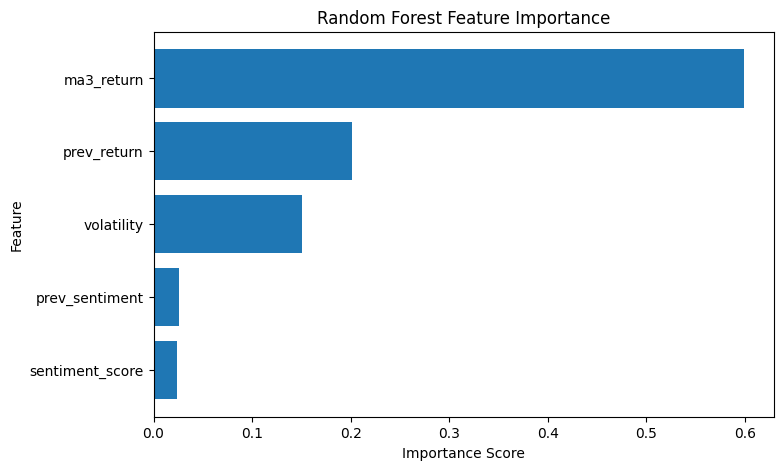

,feature,importance
3,ma3_return,0.598957
2,prev_return,0.201225
4,volatility,0.150879
1,prev_sentiment,0.025442
0,sentiment_score,0.023497


In [23]:
importance_df = pd.DataFrame({
    "feature": market_features,
    "importance": best_rf.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

importance_df

## Overall Model Performance Comparison

A final comparative analysis was conducted across all implemented models, including TF-IDF + Logistic Regression, FinBERT, Logistic Regression market model, Random Forest, and the tuned Random Forest model.

Results showed that transformer-based text classification and tuned ensemble learning approaches delivered the strongest performance in their respective tasks. FinBERT achieved superior sentiment classification accuracy, while the tuned Random Forest model produced the best market direction prediction accuracy.

This comparison highlights the value of selecting models according to task complexity: transformer models excel in language understanding, while ensemble methods perform better for nonlinear financial prediction problems.

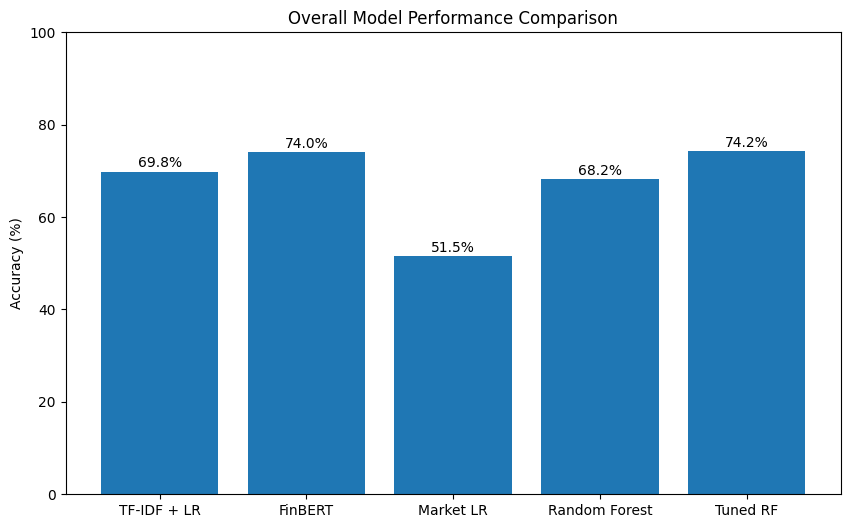

In [24]:
results_models = [
    "TF-IDF + LR",
    "FinBERT",
    "Market LR",
    "Random Forest",
    "Tuned RF"
]

results_scores = [
    tfidf_accuracy * 100,
    finbert_accuracy * 100,
    market_lr_accuracy * 100,
    market_rf_accuracy * 100,
    best_rf_accuracy * 100
]

plt.figure(figsize=(10, 6))

bars = plt.bar(results_models, results_scores)

plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("Overall Model Performance Comparison")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 1,
        f"{h:.1f}%",
        ha="center"
    )

plt.show()

## Financial Sentiment Class Distribution

The distribution of sentiment labels within the financial news dataset was visualized to assess class balance.

Results show that the **neutral** class was the most frequent, followed by **positive**, while **negative** headlines were least represented. This imbalance may influence model learning behavior, particularly reducing predictive performance for minority classes.

Understanding class distribution is important when interpreting evaluation metrics and selecting appropriate modeling strategies.

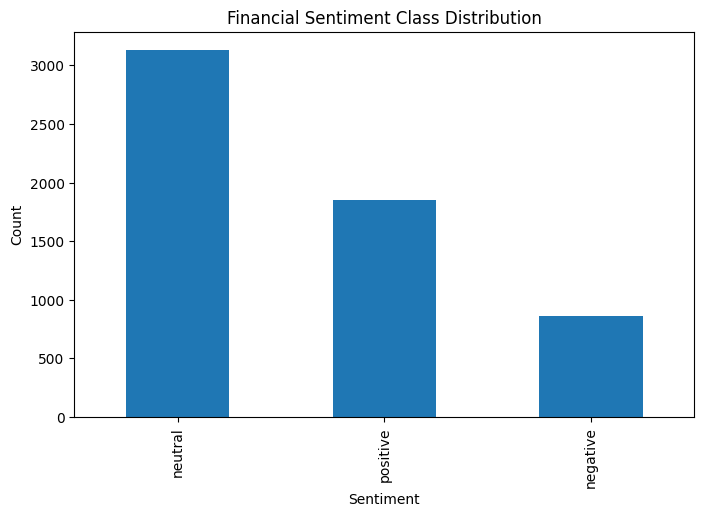

In [25]:
df["true_sentiment"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Financial Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## Feature Correlation Heatmap

A correlation heatmap was generated to examine linear relationships among engineered sentiment and market variables.

This visualization helps identify whether features are highly related, weakly associated, or largely independent. In this study, most variables showed relatively low to moderate correlations, suggesting that the selected features contributed distinct information to the predictive models.

Correlation analysis is useful for detecting multicollinearity and supporting effective feature selection.

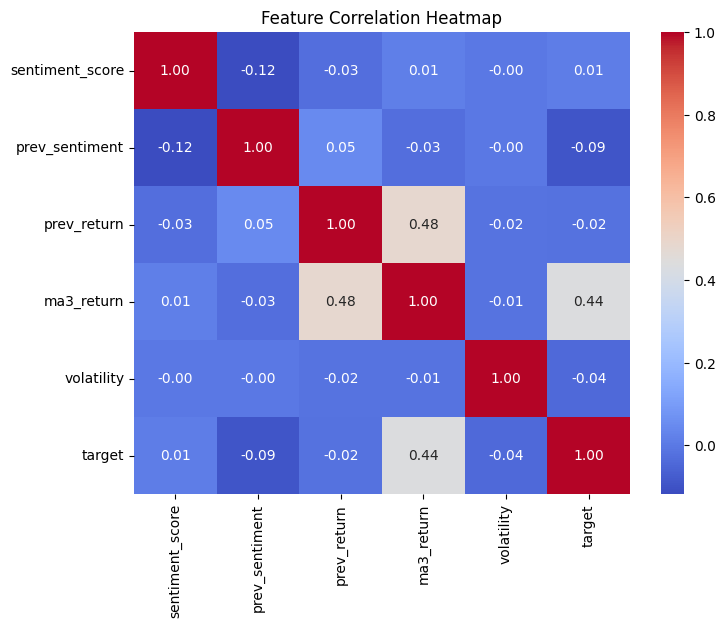

In [26]:
corr_features = model_df[
    [
        "sentiment_score",
        "prev_sentiment",
        "prev_return",
        "ma3_return",
        "volatility",
        "target"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_features,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

# Conclusion

This project investigated whether financial news sentiment can be used to support stock market direction prediction by integrating natural language processing techniques with machine learning models. Two major tasks were completed: sentiment classification of financial headlines and market movement prediction using engineered sentiment and return-based features.

For sentiment analysis, a traditional TF-IDF + Logistic Regression baseline was compared with the transformer-based FinBERT model. Results showed that FinBERT achieved stronger overall classification performance, demonstrating the advantage of domain-specific transformer models in understanding financial language and context.

For market prediction, Logistic Regression and Random Forest classifiers were evaluated using sentiment_score, lagged sentiment, previous returns, rolling average returns, and volatility indicators. Logistic Regression produced limited predictive performance, while Random Forest significantly improved results by capturing nonlinear relationships among variables. After hyperparameter tuning with GridSearchCV, the final Random Forest model achieved the strongest market prediction accuracy.

Feature importance analysis revealed that recent market return variables and volatility contributed more strongly than sentiment-only features, suggesting that sentiment is informative when combined with historical market behavior rather than used in isolation.

Overall, the study demonstrates that financial sentiment can add predictive value, especially when integrated with quantitative market indicators and modeled using more flexible machine learning approaches.  
Future improvements will include; larger historical datasets, real-time timestamped news feeds, and advanced sequence models such as LSTM or Transformers for time-series forecasting.